<center><h1>TP 4: Réseaux de Neurones Convolutifs- Optimsation et regularisation</h1></center>

## Avant de commencer le TP,
- vérifiez que vous êtes sur un environnement GPU et python 3 :
  
  Éxecution -> Modifier le type d'éxecution -> Type d'éxecution = python3, Accélerateur matériel = GPU

- Fichier -> Sauvegarder une copie dans mon drive


Considérant un filtre de convolution de taille k, avec un padding p et un stride s, pour une entrée de taille x × y × z, quelle est la taille de sortie et le nombre de poids à apprendre ?

**Réponse :**  
La taille de sortie est donnée par :

$$
n'_x = \frac{x - k + 2p}{s} + 1, \quad n'_y = \frac{y - k + 2p}{s} + 1
$$

La profondeur de la sortie correspond au nombre de filtres utilisés.  

Le nombre de paramètres à apprendre pour un filtre est :

$$
k \times k \times z
$$

La convolution permet de réduire significativement le nombre de paramètres grâce au partage des poids, contrairement à une couche fully-connected.


Quels sont les avantages des convolutions par rapport aux couches fully-connected ?

**Réponse :**  
Les convolutions permettent de réduire le nombre de paramètres grâce au partage des poids et exploitent la structure spatiale des images. Elles sont particulièrement adaptées aux données visuelles. Leur principale limite est qu’elles capturent essentiellement des dépendances locales.


Quel est l’intérêt du pooling spatial ?

**Réponse :**  
Le pooling permet de réduire la dimension spatiale des représentations, de diminuer le coût de calcul et d’améliorer la robustesse du modèle aux petites variations des données. Il contribue également à limiter le sur-apprentissage.

In [ ]:
! wget https://raw.githubusercontent.com/deep-learning-polytech/deep-learning-polytech.github.io/master/code/TP5-6/utils.py

--2026-04-18 08:58:19--  https://raw.githubusercontent.com/deep-learning-polytech/deep-learning-polytech.github.io/master/code/TP5-6/utils.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2627 (2.6K) [text/plain]
Saving to: ‘utils.py’

utils.py            100%[===================>]   2.57K  --.-KB/s    in 0s      

2026-04-18 08:58:19 (48.9 MB/s) - ‘utils.py’ saved [2627/2627]



In [ ]:
import argparse
import os
import time

import torch
import torch.nn as nn
import torch.nn.parallel
import torch.backends.cudnn as cudnn
import torch.optim
import torch.utils.data
import torchvision.transforms as transforms
import torchvision.datasets as datasets

from utils import *

PRINT_INTERVAL = 200
PATH="datasets"

In [ ]:
class ConvNet(nn.Module):
    """
    Cette classe contient la structure du réseau de neurones
    """

    def __init__(self):
        super(ConvNet, self).__init__()
        # On défini d'abord les couches de convolution et de pooling comme un
        # groupe de couches `self.features`
        self.features = nn.Sequential(
            nn.Conv2d(1, 6, (5, 5), stride=1, padding=2),
            nn.Tanh(),
            nn.MaxPool2d((2, 2), stride=2, padding=0),
            nn.Conv2d(6, 16, (5, 5), stride=1, padding=0),
            nn.Tanh(),
            nn.MaxPool2d((2, 2), stride=2, padding=0),
        )
        # On défini les couches fully connected comme un groupe de couches
        # `self.classifier`
        self.classifier = nn.Sequential(
            nn.Linear(400, 120),
            nn.Tanh(),
            nn.Linear(120, 84),
            nn.Tanh(),
            nn.Linear(84, 10)
            # Rappel : Le softmax est inclus dans la loss, ne pas le mettre ici
        )

    # méthode appelée quand on applique le réseau à un batch d'input
    def forward(self, input):
        bsize = input.size(0) # taille du batch
        output = self.features(input) # on calcule la sortie des conv
        output = output.view(bsize, -1) # on applati les feature map 2D en un
                                        # vecteur 1D pour chaque input
        output = self.classifier(output) # on calcule la sortie des fc
        return output



def get_dataset(batch_size, cuda=False):
    """
    Cette fonction charge le dataset et effectue des transformations sur chaqu
    image (listées dans `transform=...`).
    """
    train_dataset = datasets.MNIST(PATH, train=True, download=True,
        transform=transforms.Compose([
            transforms.ToTensor()
        ]))
    val_dataset = datasets.MNIST(PATH, train=False, download=True,
        transform=transforms.Compose([
            transforms.ToTensor()
        ]))

    train_loader = torch.utils.data.DataLoader(train_dataset,
                        batch_size=batch_size, shuffle=True, pin_memory=cuda, num_workers=2)
    val_loader = torch.utils.data.DataLoader(val_dataset,
                        batch_size=batch_size, shuffle=False, pin_memory=cuda, num_workers=2)

    return train_loader, val_loader



def epoch(data, model, criterion, optimizer=None, cuda=False):
    """
    Fait une passe (appelée epoch en anglais) sur les données `data` avec le
    modèle `model`. Evalue `criterion` comme loss.
    Si `optimizer` est fourni, effectue une epoch d'apprentissage en utilisant
    l'optimiseur donné, sinon, effectue une epoch d'évaluation (pas de backward)
    du modèle.
    """

    # indique si le modele est en mode eval ou train (certaines couches se
    # comportent différemment en train et en eval)
    model.eval() if optimizer is None else model.train()

    # objets pour stocker les moyennes des metriques
    avg_loss = AverageMeter()
    avg_top1_acc = AverageMeter()
    avg_top5_acc = AverageMeter()
    avg_batch_time = AverageMeter()
    global loss_plot

    # on itere sur les batchs du dataset
    tic = time.time()
    for i, (input, target) in enumerate(data):

        if cuda: # si on fait du GPU, passage en CUDA
            input = input.cuda()
            target = target.cuda()

        # forward
        output = model(input)
        loss = criterion(output, target)

        # backward si on est en "train"
        if optimizer:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # calcul des metriques
        prec1, prec5 = accuracy(output, target, topk=(1, 5))
        batch_time = time.time() - tic
        tic = time.time()

        # mise a jour des moyennes
        avg_loss.update(loss.item())
        avg_top1_acc.update(prec1.item())
        avg_top5_acc.update(prec5.item())
        avg_batch_time.update(batch_time)
        if optimizer:
            loss_plot.update(avg_loss.val)
        # affichage des infos
        if i % PRINT_INTERVAL == 0:
            print('[{0:s} Batch {1:03d}/{2:03d}]\t'
                  'Time {batch_time.val:.3f}s ({batch_time.avg:.3f}s)\t'
                  'Loss {loss.val:.4f} ({loss.avg:.4f})\t'
                  'Prec@1 {top1.val:5.1f} ({top1.avg:5.1f})\t'
                  'Prec@5 {top5.val:5.1f} ({top5.avg:5.1f})'.format(
                   "EVAL" if optimizer is None else "TRAIN", i, len(data), batch_time=avg_batch_time, loss=avg_loss,
                   top1=avg_top1_acc, top5=avg_top5_acc))
            if optimizer:
                loss_plot.plot()

    # Affichage des infos sur l'epoch
    print('\n===============> Total time {batch_time:d}s\t'
          'Avg loss {loss.avg:.4f}\t'
          'Avg Prec@1 {top1.avg:5.2f} %\t'
          'Avg Prec@5 {top5.avg:5.2f} %\n'.format(
           batch_time=int(avg_batch_time.sum), loss=avg_loss,
           top1=avg_top1_acc, top5=avg_top5_acc))

    return avg_top1_acc, avg_top5_acc, avg_loss


def main(batch_size=128, lr=0.1, epochs=5, cuda=False):

    # ex de params :
    #   {"batch_size": 128, "epochs": 5, "lr": 0.1}

    # define model, loss, optim
    model = ConvNet()
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr)

    if cuda: # si on fait du GPU, passage en CUDA
        cudnn.benchmark = True
        model = model.cuda()
        criterion = criterion.cuda()

    # On récupère les données
    train, test = get_dataset(batch_size, cuda)

    # init plots
    plot = AccLossPlot()
    global loss_plot
    loss_plot = TrainLossPlot()

    # On itère sur les epochs
    for i in range(epochs):
        print("=================\n=== EPOCH "+str(i+1)+" =====\n=================\n")
        # Phase de train
        top1_acc, avg_top5_acc, loss = epoch(train, model, criterion, optimizer, cuda)
        # Phase d'evaluation
        top1_acc_test, top5_acc_test, loss_test = epoch(test, model, criterion, cuda=cuda)
        # plot
        plot.update(loss.avg, loss_test.avg, top1_acc.avg, top1_acc_test.avg)


Le réseau contient :
- deux couches de convolution avec activation `Tanh` ;
- deux couches de `MaxPool2d` ;
- trois couches fully-connected ;
- une loss `CrossEntropyLoss`, qui inclut déjà le softmax ;
- un optimiseur `SGD`.

La fonction `get_dataset` charge les données MNIST et applique `ToTensor()`.

La fonction `epoch` effectue soit :
- une phase d’apprentissage si un `optimizer` est donné ;
- une phase d’évaluation si aucun `optimizer` n’est donné.

La fonction `main` crée le modèle, la loss, l’optimiseur, charge les données, puis lance plusieurs époques d’apprentissage et d’évaluation.


La différence importante entre le calcul en **train** et en **test** est liée à la présence ou non de l’optimiseur.

En phase de **train**, la fonction `epoch` reçoit un `optimizer`. Le modèle est mis en mode `train()` et le code effectue :
```python
optimizer.zero_grad()
loss.backward()
optimizer.step()
```

Donc les gradients sont calculés et les poids du réseau sont mis à jour.

En phase de **test**, la fonction `epoch` est appelée sans `optimizer`. Le modèle est mis en mode `eval()` et il n’y a pas de rétropropagation ni de mise à jour des poids.

La loss et l’accuracy sont donc calculées uniquement pour évaluer le modèle.

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 498kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.66MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.27MB/s]

=== EPOCH 1 =====



[TRAIN Batch 000/469]	Time 1.611s (1.611s)	Loss 2.3006 (2.3006)	Prec@1  11.7 ( 11.7)	Prec@5  47.7 ( 47.7)


<Figure size 640x480 with 0 Axes>

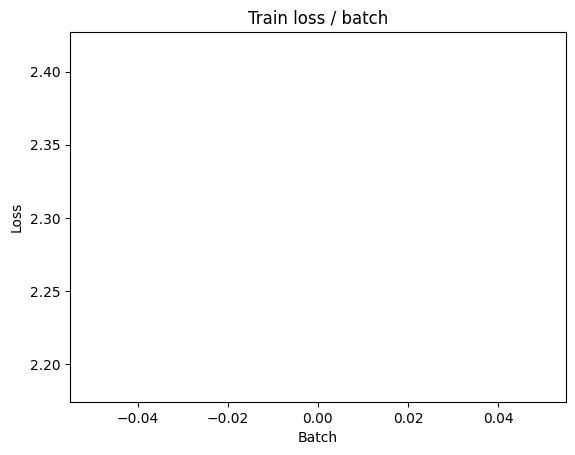

[TRAIN Batch 200/469]	Time 0.012s (0.023s)	Loss 0.3273 (1.0951)	Prec@1  93.0 ( 71.6)	Prec@5  99.2 ( 93.2)


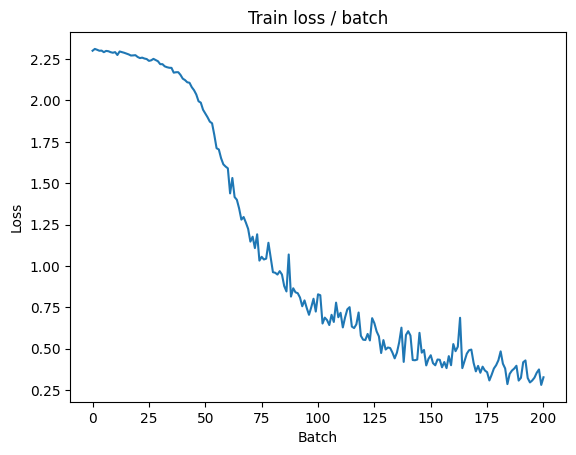

[TRAIN Batch 400/469]	Time 0.020s (0.022s)	Loss 0.1644 (0.6748)	Prec@1  96.1 ( 82.2)	Prec@5 100.0 ( 96.4)


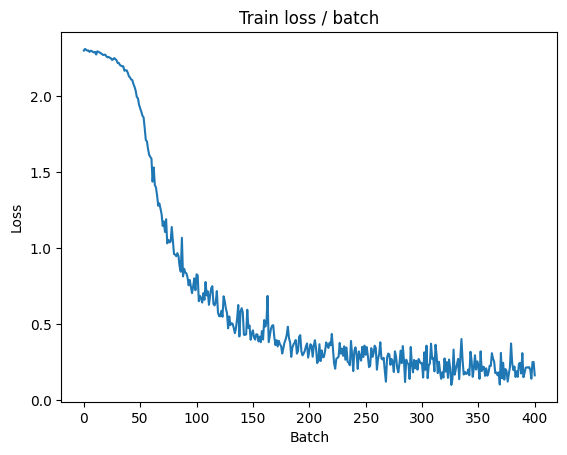


===============> Total time 9s	Avg loss 0.6010	Avg Prec@1 84.12 %	Avg Prec@5 96.93 %

[EVAL Batch 000/079]	Time 0.084s (0.084s)	Loss 0.0809 (0.0809)	Prec@1  97.7 ( 97.7)	Prec@5 100.0 (100.0)

===============> Total time 1s	Avg loss 0.1440	Avg Prec@1 95.72 %	Avg Prec@5 99.96 %



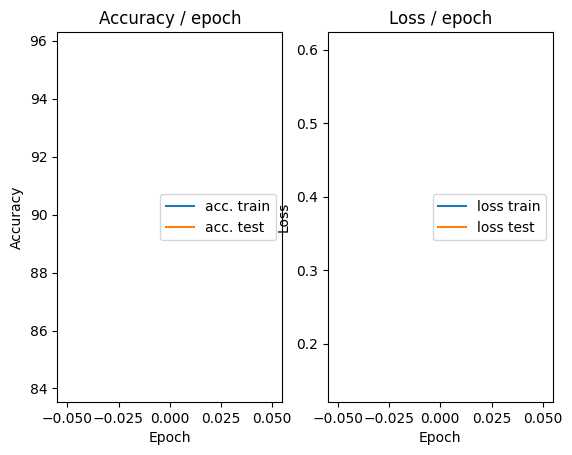

=== EPOCH 2 =====

[TRAIN Batch 000/469]	Time 0.104s (0.104s)	Loss 0.1714 (0.1714)	Prec@1  93.0 ( 93.0)	Prec@5 100.0 (100.0)


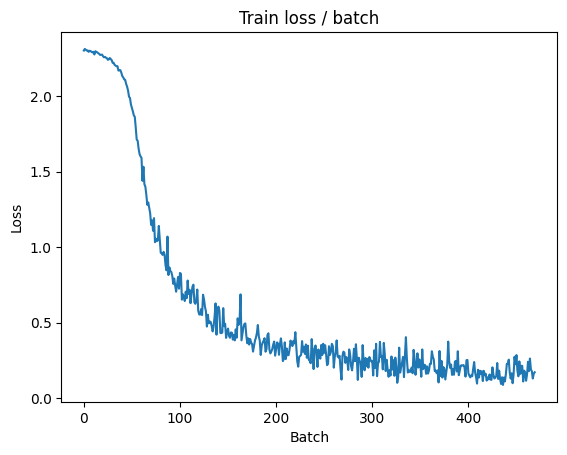

[TRAIN Batch 200/469]	Time 0.017s (0.016s)	Loss 0.1653 (0.1366)	Prec@1  96.1 ( 96.0)	Prec@5 100.0 ( 99.9)


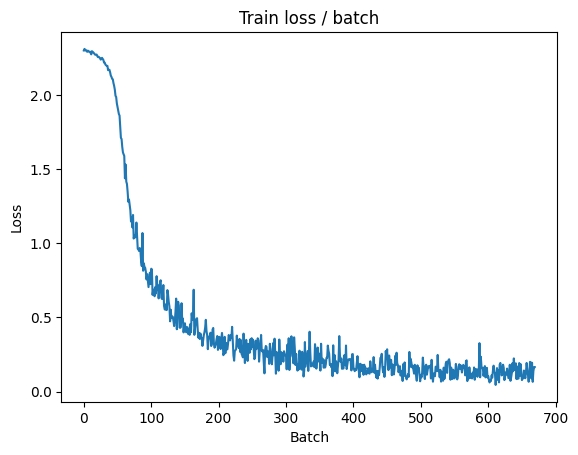

[TRAIN Batch 400/469]	Time 0.010s (0.017s)	Loss 0.0780 (0.1242)	Prec@1  97.7 ( 96.4)	Prec@5 100.0 ( 99.9)


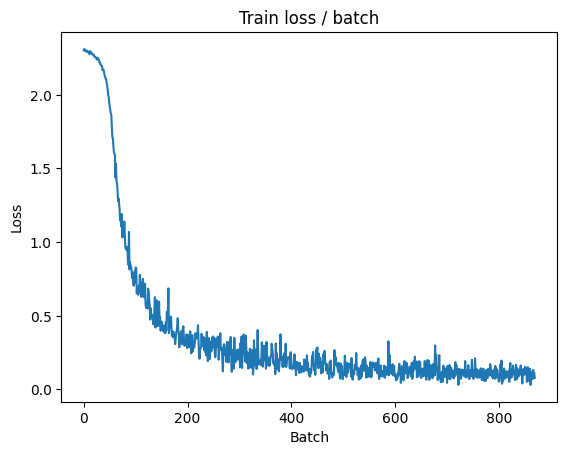


===============> Total time 8s	Avg loss 0.1200	Avg Prec@1 96.48 %	Avg Prec@5 99.90 %

[EVAL Batch 000/079]	Time 0.143s (0.143s)	Loss 0.0391 (0.0391)	Prec@1  99.2 ( 99.2)	Prec@5 100.0 (100.0)

===============> Total time 1s	Avg loss 0.0822	Avg Prec@1 97.46 %	Avg Prec@5 99.99 %



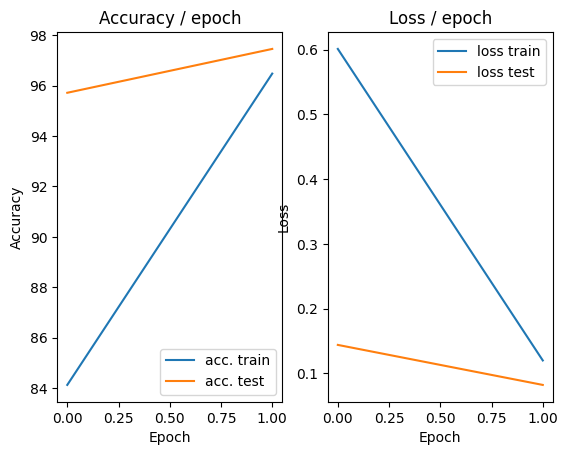

=== EPOCH 3 =====

[TRAIN Batch 000/469]	Time 0.110s (0.110s)	Loss 0.0947 (0.0947)	Prec@1  96.9 ( 96.9)	Prec@5 100.0 (100.0)


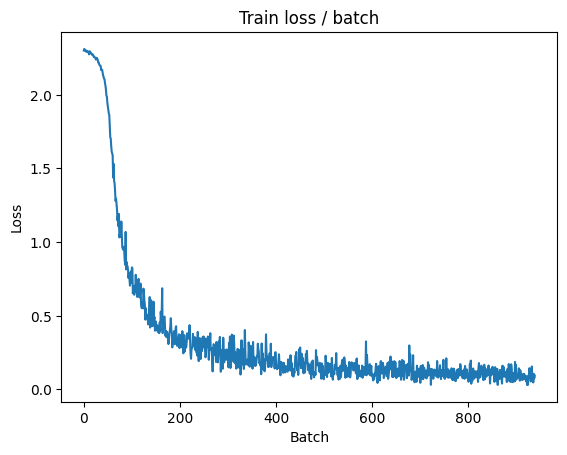

[TRAIN Batch 200/469]	Time 0.022s (0.019s)	Loss 0.1122 (0.0867)	Prec@1  96.9 ( 97.4)	Prec@5  99.2 ( 99.9)


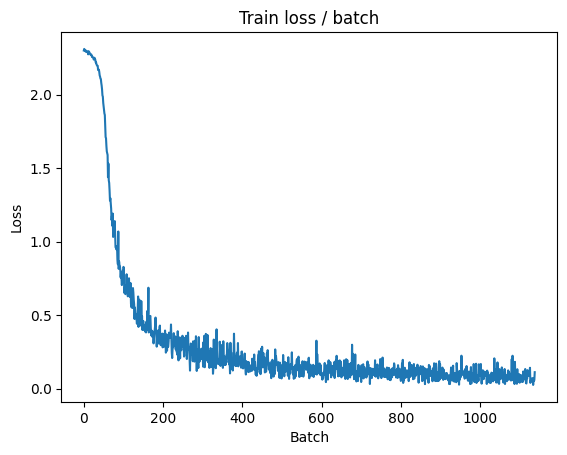

[TRAIN Batch 400/469]	Time 0.013s (0.017s)	Loss 0.0252 (0.0817)	Prec@1 100.0 ( 97.6)	Prec@5 100.0 ( 99.9)


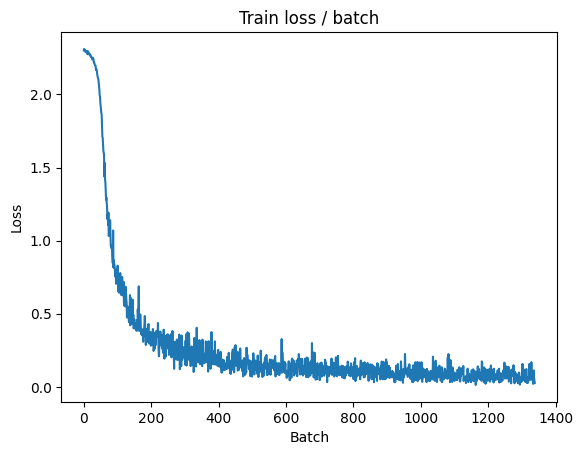


===============> Total time 7s	Avg loss 0.0808	Avg Prec@1 97.62 %	Avg Prec@5 99.94 %

[EVAL Batch 000/079]	Time 0.088s (0.088s)	Loss 0.0254 (0.0254)	Prec@1 100.0 (100.0)	Prec@5 100.0 (100.0)

===============> Total time 1s	Avg loss 0.0592	Avg Prec@1 98.20 %	Avg Prec@5 100.00 %



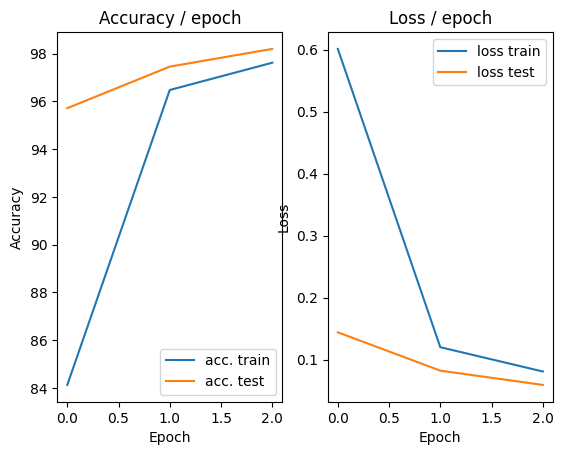

=== EPOCH 4 =====

[TRAIN Batch 000/469]	Time 0.155s (0.155s)	Loss 0.0628 (0.0628)	Prec@1  96.9 ( 96.9)	Prec@5 100.0 (100.0)


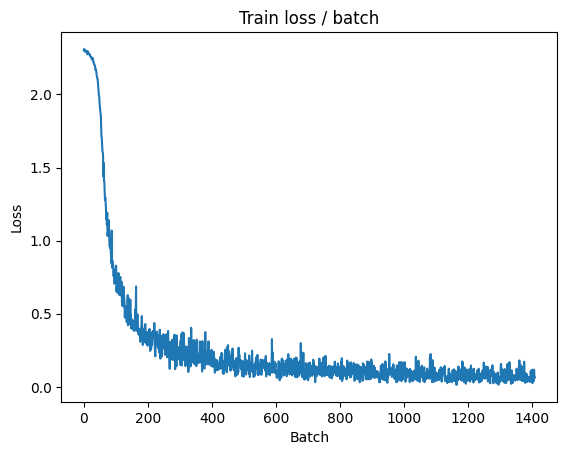

[TRAIN Batch 200/469]	Time 0.020s (0.021s)	Loss 0.0664 (0.0677)	Prec@1  98.4 ( 97.9)	Prec@5 100.0 (100.0)


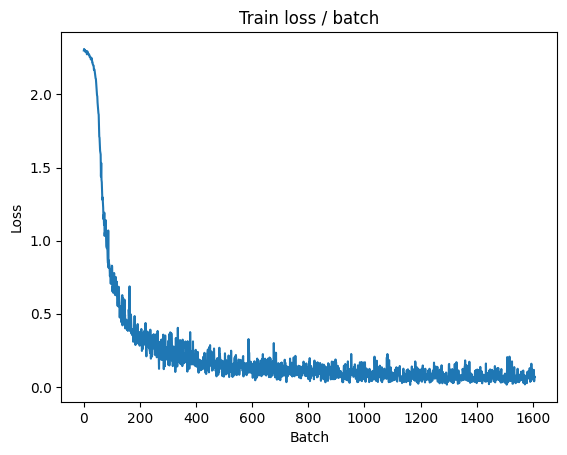

[TRAIN Batch 400/469]	Time 0.004s (0.019s)	Loss 0.0080 (0.0641)	Prec@1 100.0 ( 98.0)	Prec@5 100.0 (100.0)


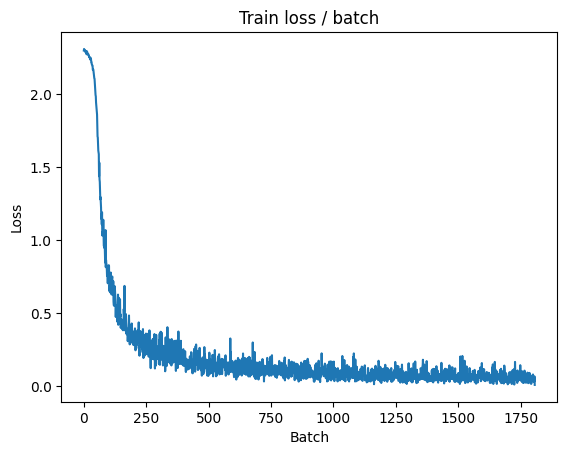


===============> Total time 8s	Avg loss 0.0630	Avg Prec@1 98.07 %	Avg Prec@5 99.97 %

[EVAL Batch 000/079]	Time 0.091s (0.091s)	Loss 0.0144 (0.0144)	Prec@1 100.0 (100.0)	Prec@5 100.0 (100.0)

===============> Total time 1s	Avg loss 0.0536	Avg Prec@1 98.38 %	Avg Prec@5 99.99 %



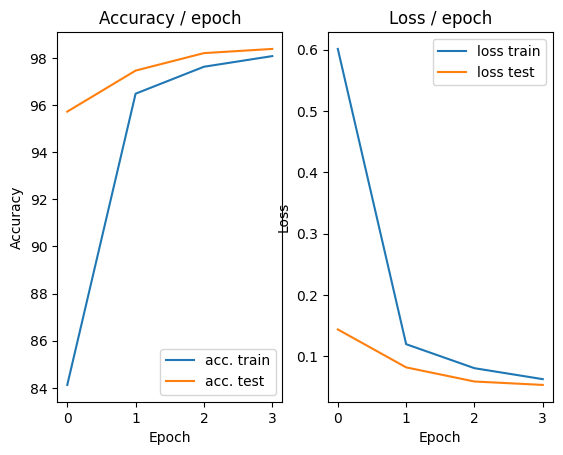

=== EPOCH 5 =====

[TRAIN Batch 000/469]	Time 0.113s (0.113s)	Loss 0.0191 (0.0191)	Prec@1 100.0 (100.0)	Prec@5 100.0 (100.0)


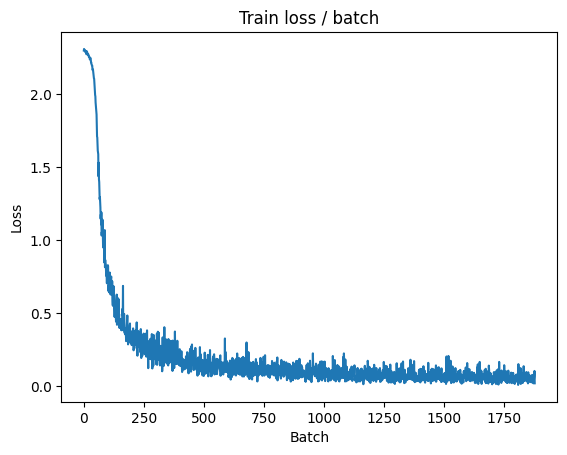

[TRAIN Batch 200/469]	Time 0.007s (0.020s)	Loss 0.0919 (0.0530)	Prec@1  96.1 ( 98.4)	Prec@5 100.0 (100.0)


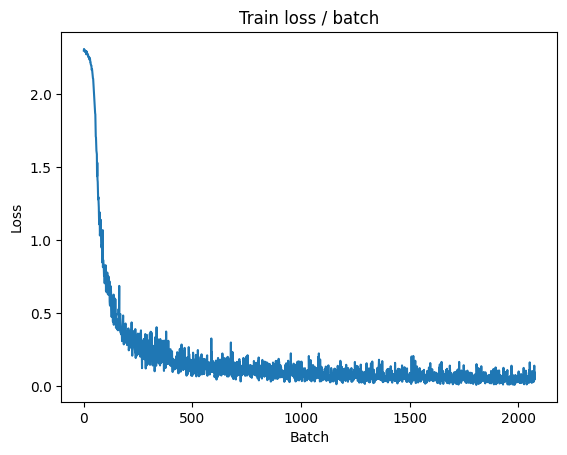

[TRAIN Batch 400/469]	Time 0.014s (0.019s)	Loss 0.0233 (0.0535)	Prec@1 100.0 ( 98.4)	Prec@5 100.0 (100.0)


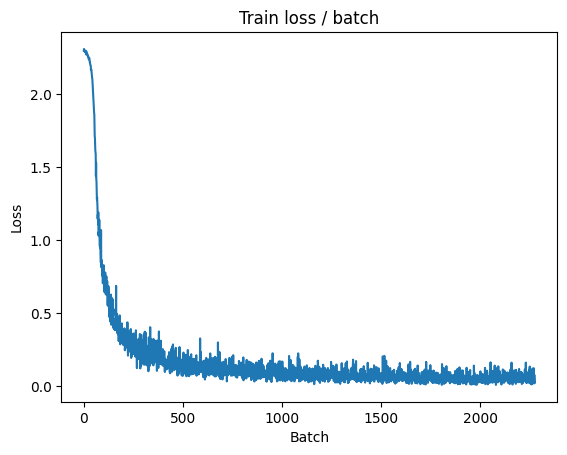


===============> Total time 8s	Avg loss 0.0526	Avg Prec@1 98.42 %	Avg Prec@5 99.98 %

[EVAL Batch 000/079]	Time 0.089s (0.089s)	Loss 0.0103 (0.0103)	Prec@1 100.0 (100.0)	Prec@5 100.0 (100.0)

===============> Total time 1s	Avg loss 0.0446	Avg Prec@1 98.65 %	Avg Prec@5 100.00 %



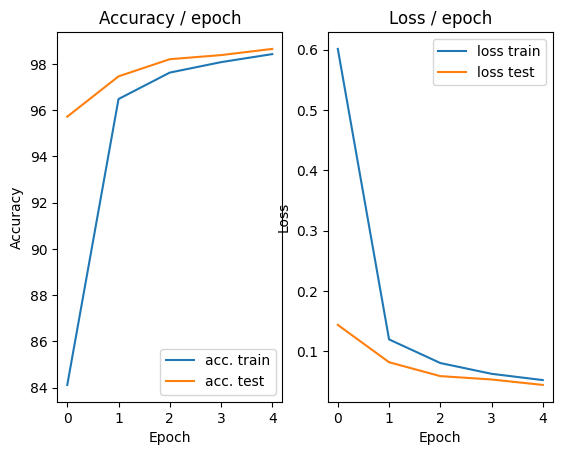

In [ ]:
main(128, 0.1, cuda=True)

Au début de l’apprentissage, les poids du réseau sont initialisés de manière aléatoire, ce qui signifie que le modèle n’a encore appris aucune structure des données. Dans ces conditions, les sorties du réseau après la fonction softmax sont proches d’une distribution uniforme sur les différentes classes. Étant donné que la base MNIST contient 10 classes, chaque classe reçoit une probabilité similaire, ce qui correspond à un comportement de prédiction aléatoire. Par conséquent, l’accuracy initiale du modèle est proche de 10 %, ce qui est cohérent avec un classifieur aléatoire.

En utilisant une fonction de coût de type entropie croisée, la perte associée à une telle prédiction est donnée par :

−log(0.1)=log(10)≈2.3

Ainsi, une loss initiale d’environ 2.3 et une accuracy proche de 10 % caractérisent un modèle non entraîné. Ces valeurs servent de référence pour vérifier que l’apprentissage progresse correctement au cours des itérations.